In [15]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso

In [16]:
x=load_diabetes()
df=pd.DataFrame(x.data,columns=x.feature_names)
df["Target"]=x.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [32]:
from sklearn.model_selection  import train_test_split
import matplotlib.pyplot as plt
x_train,x_test,y_train,y_test=train_test_split(x.data,x.target,test_size=0.2,random_state=42)
y_test


array([219.,  70., 202., 230., 111.,  84., 242., 272.,  94.,  96.,  94.,
       252.,  99., 297., 135.,  67., 295., 264., 170., 275., 310.,  64.,
       128., 232., 129., 118., 263.,  77.,  48., 107., 140., 113.,  90.,
       164., 180., 233.,  42.,  84., 172.,  63.,  48., 108., 156., 168.,
        90.,  52., 200.,  87.,  90., 258., 136., 158.,  69.,  72., 171.,
        95.,  72., 151., 168.,  60., 122.,  52., 187., 102., 214., 248.,
       181., 110., 140., 202., 101., 222., 281.,  61.,  89.,  91., 186.,
       220., 237., 233.,  68., 190.,  96.,  72., 153.,  98.,  37.,  63.,
       184.])

In [40]:
coefs=[]
r2_scores=[]
for i in [0,0.1,1,10]:
    reg=Lasso(alpha=i)
    reg.fit(x_train,y_train)
    coefs.append(reg.coef_.tolist())
    y_pred=reg.predict(x_test)
    r2_scores.append(r2_score(y_test,y_pred))
   
    

/home/srabon/.local/lib/python3.10/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/srabon/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/srabon/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.063e+05, tolerance: 2.145e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_f

Text(0.5, 1.0, 'Alpha=0,r2_score=0.45')

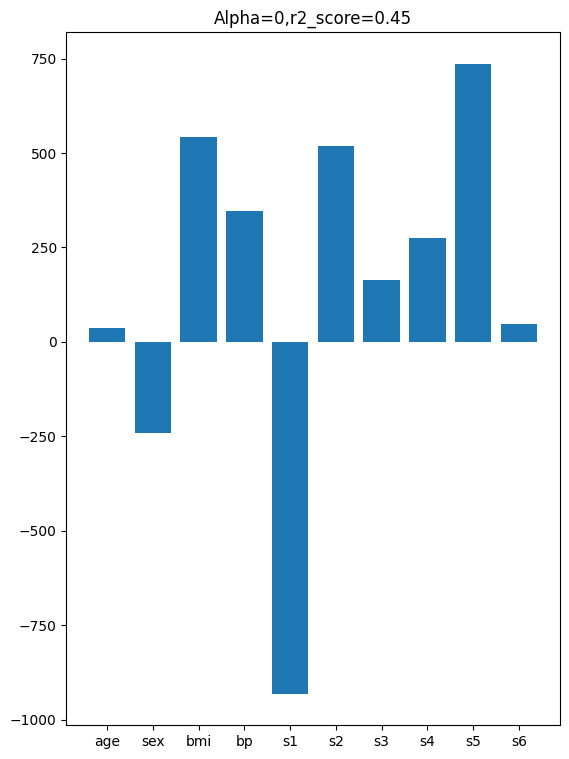

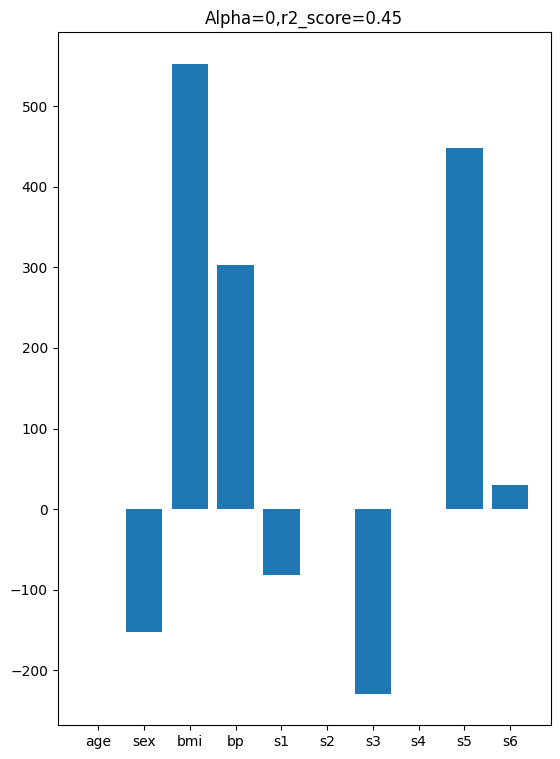

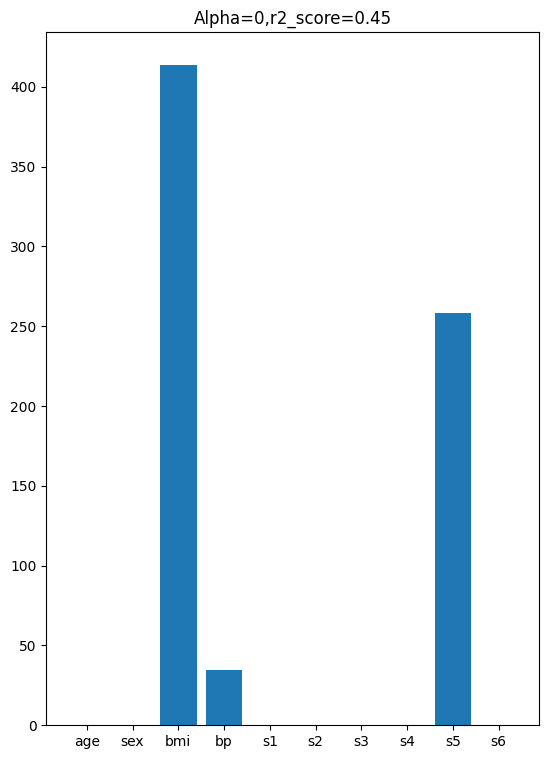

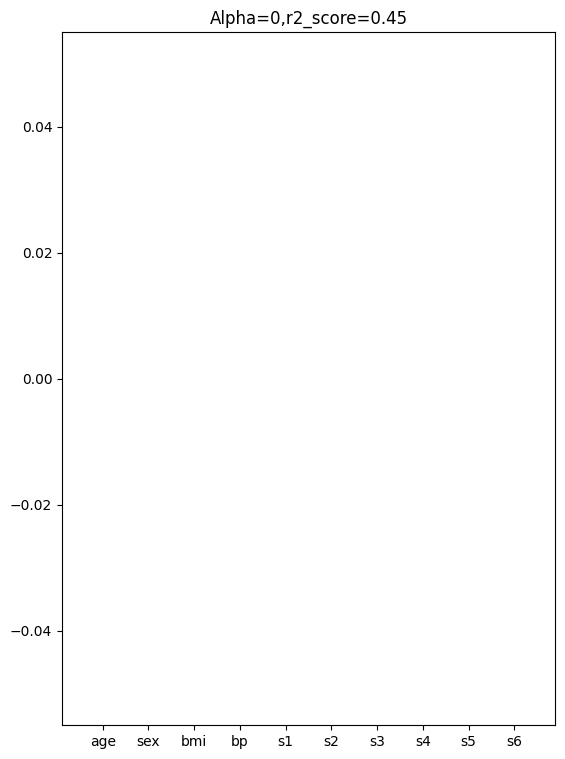

In [39]:
    plt.figure(figsize=(14,9))
    plt.subplot(121)
    plt.bar(x.feature_names,coefs[0])
    plt.title('Alpha=0,r2_score={}'.format(round(r2_scores[0],2)))
    plt.figure(figsize=(14,9))
    plt.subplot(121)
    plt.bar(x.feature_names,coefs[1])
    plt.title('Alpha=0,r2_score={}'.format(round(r2_scores[0],2)))
    plt.figure(figsize=(14,9))
    plt.subplot(121)
    plt.bar(x.feature_names,coefs[2])
    plt.title('Alpha=0,r2_score={}'.format(round(r2_scores[0],2)))
    plt.figure(figsize=(14,9))
    plt.subplot(121)
    plt.bar(x.feature_names,coefs[3])
    plt.title('Alpha=0,r2_score={}'.format(round(r2_scores[0],2)))
#  তার  মানে  হল  ল্যাম্বডা  /আলফা বারতে থাকলে  যেসব   কলাম  কম গুরুত্বপূর্ণ সগুলো    এর অংশ বা  কফিসিএন্ত  জির হয়ে যাবে




In [26]:
from sklearn.linear_model import Ridge

In [21]:
reg=Ridge(alpha=0.1,solver='cholesky')

In [22]:
reg.fit(x_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [23]:
y_pred=reg.predict(x_test)
r2_score(y_test,y_pred)

0.45199494197195456

In [24]:
print(reg.coef_)
print(reg.intercept_)

[   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
151.92546856900984


In [25]:
## This is my code:
class Mridge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None
    def fit(self,x,y):
        x=np.insert(x,0,1,axis=1)
        I=np.identity(x.shape[1])
        result=np.linalg.inv(np.dot(x.T,x)+self.alpha*I).dot(x.T).dot(y)
        self.intercept_=result[0]
        self.coef_=result[1:]
           
    def predict(self,x_test):
        return np.dot(x_test,self.coef_)+self.intercept_

In [26]:
reg=Mridge()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)


0.4519719082031616
[   6.64970105 -172.2493574   485.49941498  314.68335483  -72.93919534
  -80.6014393  -174.45279965   83.5733994   484.39865564   73.58483208]
151.88221592211522


In [27]:
## which is same as built in class shows:

In [28]:
#Gradient use by sklearn:
from sklearn.linear_model import SGDRegressor

In [33]:
sreg=SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant', alpha=0.001) 

In [34]:
sreg.fit(x_train,y_train)

SGDRegressor(alpha=0.001, eta0=0.1, learning_rate='constant', max_iter=500)

In [35]:
print(sreg.intercept_)
print(sreg.coef_)
print(r2_score(y_test,sreg.predict(x_test)))

[159.61506128]
[  26.95805935 -113.23762471  393.54823582  268.54747003   -9.69734195
  -67.29441348 -168.20928771  106.71156366  359.57335761   99.63498755]
0.4402349921847928


In [36]:
class MRidge_gra:
    def __init__(self,epoches,learning_rate,alpha):
        self.learning_rate=learning_rate
        self.epoches=epoches
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None
    def fit(self,x_train,y_train):
        self.coef_=np.ones(x_train.shape[1])
        self.intercept_=0
        theata=np.insert(self.coef_,0,self.intercept_)
        x_train=np.insert(x_train,0,1,axis=1)
        for i in range()

SyntaxError: expected ':' (1779694300.py, line 2)